<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo"  />
    </a>
</p>


<h1><center>Final Assignment</center></h1>


> ***Note: Please ensure you follow the instructions outlined in the in the <a href="https://www.coursera.org/learn/supervised-machine-learning-regression/supplement/YGZt9/project-scenario">Project Scenario</a> section to complete this Final Assignment successfully.***


## Introduction

We will be working with the "Heatwave Dataset (Rajasthan, India, 2006-2025)" from Kaggle. The dataset has been downloaded, and the CSV file of the dataset has been uploaded to the notebook. Our goal is to train a model that can predict a heatwave based on different geographical factors. We will start off with a brief EDA(Exploratory Data Analysis), move on to getting the data ready to be trained on, and finally compare different regularization methods to reach an optimum level of accuracy for our model. 

## Environment Setup
Let us begin by setting up the notebook by first installing all the needed packages:

In [5]:
%pip install numpy
%pip install pandas
%pip install scikit-learn
%pip install matplotlib

Now that we have the packages installed, let's import them into our environment:

In [15]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import r2_score
from sklearn.model_selection import train_test_split

Let's now use **Pandas** to read in our CSV file containing the dataset and save it in a variable named **data**:

In [9]:
data = pd.read_csv("Rajasthan_Heatwave_2006_2025.csv")

## Environment Setup

Alright, now that we have all our libraries imported and our dataset set up, let's perform a brief Exploratory Data Analysis(EDA) on this dataset in order to understand it better

Let's take a glance at what the dataset looks like:

In [10]:
data.head()

,YEAR,MONTH,DAY,WIND_U10,WIND_V10,MSLP,BLH,GEOP,TEMP2M,TMAX,...,RAIN,SRAD,EVAP,SOILT1,SOILM1,LAI,HEATWAVE,LAT,LON,DISTRICT
0,2006,3,1,-0.223022,-0.440903,101036.375,2020.7317,1671.1079,304.75806,303.54395,...,0.0,3117056,-0.000023,312.75903,0.024887,0.515625,0,25.75,71.5,Barmer
1,2006,3,2,-1.344009,-0.294922,101076.440,2265.7910,1671.1079,306.45337,304.95703,...,0.0,3131200,-0.000024,312.66943,0.024345,0.515625,0,25.75,71.5,Barmer
2,2006,3,3,-0.960449,1.522965,101033.750,3152.6023,1671.1079,307.34863,306.21167,...,0.0,3105536,-0.000024,313.12280,0.023773,0.515625,0,25.75,71.5,Barmer
3,2006,3,4,2.704514,1.733017,100896.940,3146.9475,1671.1079,307.43457,306.70508,...,0.0,3126528,-0.000024,314.12085,0.023147,0.515625,0,25.75,71.5,Barmer
4,2006,3,5,2.717834,2.464432,101014.190,2069.5261,1671.1079,306.19507,304.88306,...,0.0,2776448,-0.000041,312.00806,0.027964,0.515625,0,25.75,71.5,Barmer


Now let's look at the type(s) of data we're working with here:

In [11]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 21960 entries, 0 to 21959
Data columns (total 23 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   YEAR      21960 non-null  int64  
 1   MONTH     21960 non-null  int64  
 2   DAY       21960 non-null  int64  
 3   WIND_U10  21960 non-null  float64
 4   WIND_V10  21960 non-null  float64
 5   MSLP      21960 non-null  float64
 6   BLH       21960 non-null  float64
 7   GEOP      21960 non-null  float64
 8   TEMP2M    21960 non-null  float64
 9   TMAX      21960 non-null  float64
 10  TMIN      21960 non-null  float64
 11  DEW2M     21960 non-null  float64
 12  CLOUD     21960 non-null  float64
 13  RAIN      21960 non-null  float64
 14  SRAD      21960 non-null  int64  
 15  EVAP      21960 non-null  float64
 16  SOILT1    21960 non-null  float64
 17  SOILM1    21960 non-null  float64
 18  LAI       21960 non-null  float64
 19  HEATWAVE  21960 non-null  int64  
 20  LAT       21960 non-null  float64
 21  

As we can see, all columns are either integers or floats, except the column "DISTRICT". Let's keep in mind to handle that when we begin to preprocess the data.

Let's look more into the relations of the data to see if we can find patterns before we construct the model. Thinking about this on a high level, chances are that in this dataset, temperature will have the greatest postive correlation with heatwave. Let's take a look:

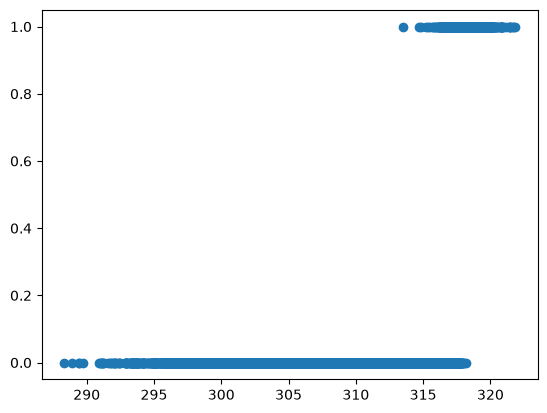

In [31]:
plt.scatter(x=data.TEMP2M, y=data.HEATWAVE)

While it is a bit hard to comprehend and might look off since the heatwave is either 0 or 1, we can see that air temperatures approximately between 290 and 312 show no signs of a heatwave, where temperatures above that start to show signs of a heatwave. We can see at around a temperature of 319, there were no recorded situations in which there wasn't a heatwave considered, at least from the data collected in the dataset. 

Looking at just binary values in the Y-axis doesn't seem too helpful, so let's see if we can make a direct correlation here. Let's do this by making a scatter plot of each column in relation to "TEMP2M":

/opt/conda/lib/python3.12/site-packages/pandas/plotting/_matplotlib/core.py:599: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig = plt.figure(figsize=self.figsize)


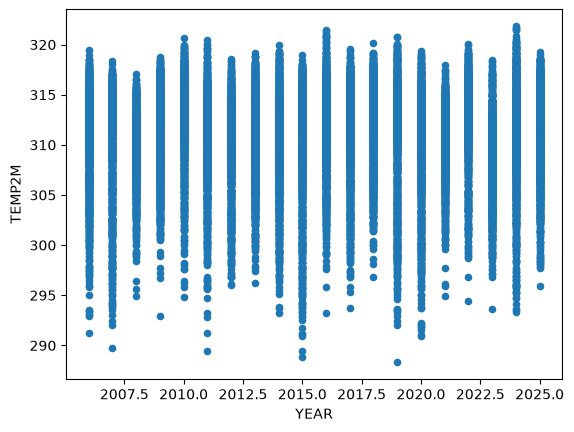

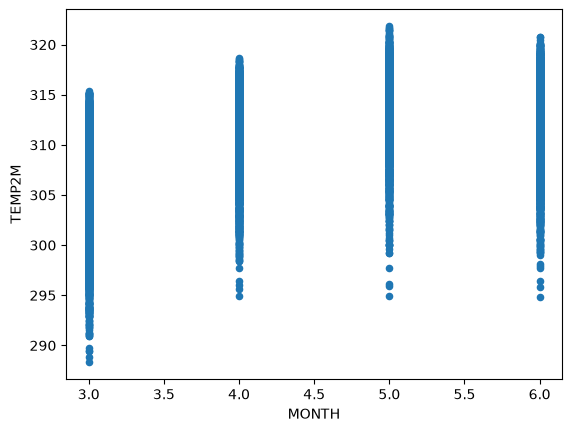

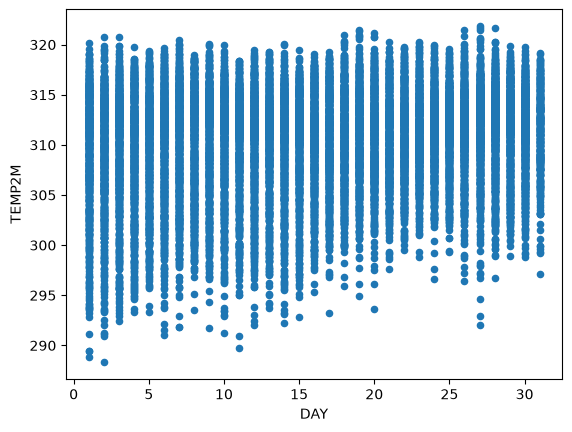

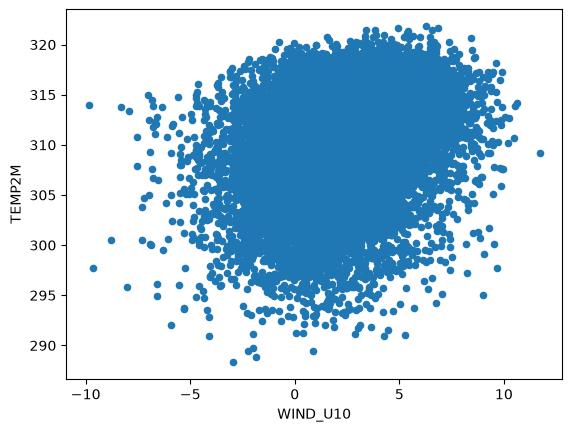

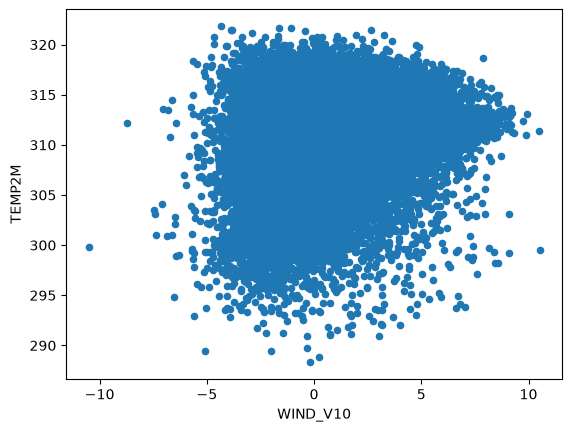

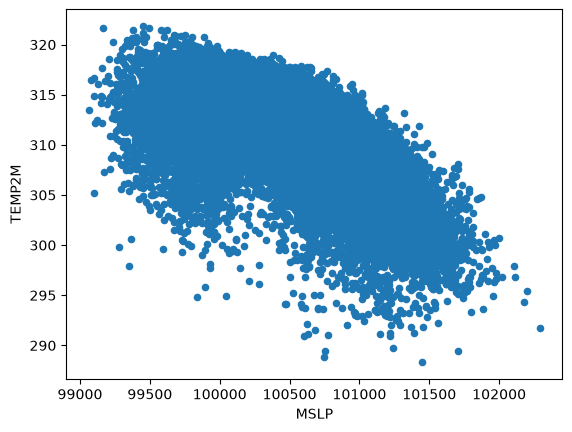

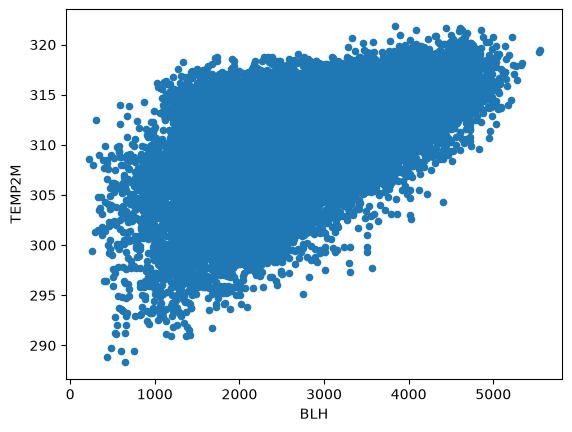

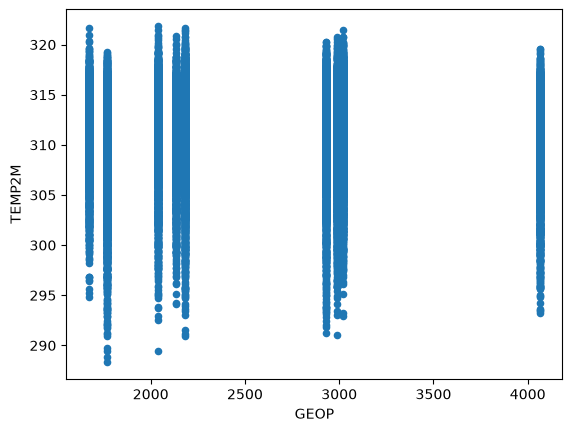

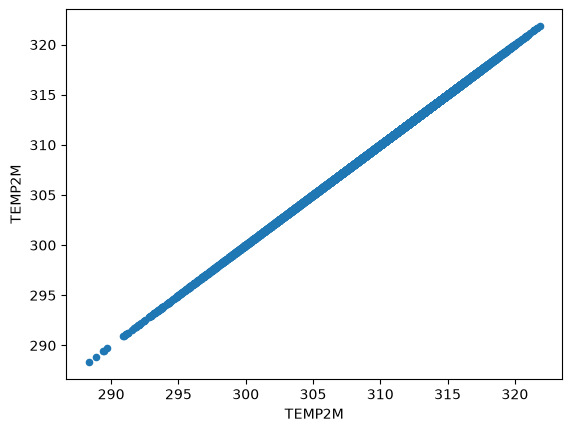

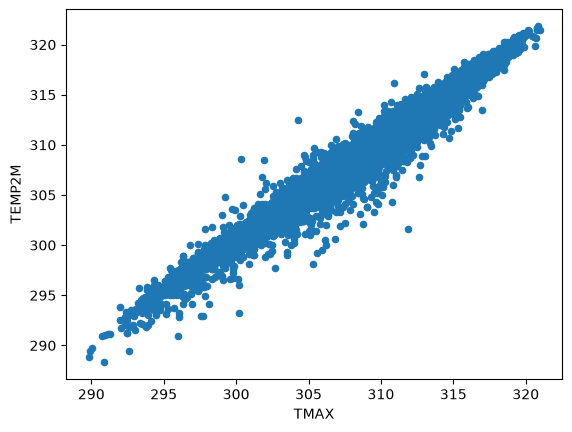

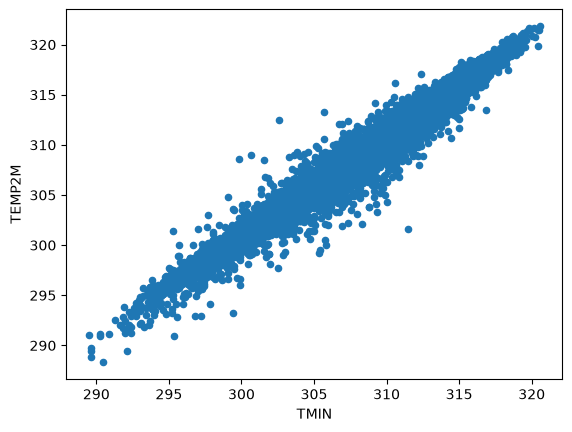

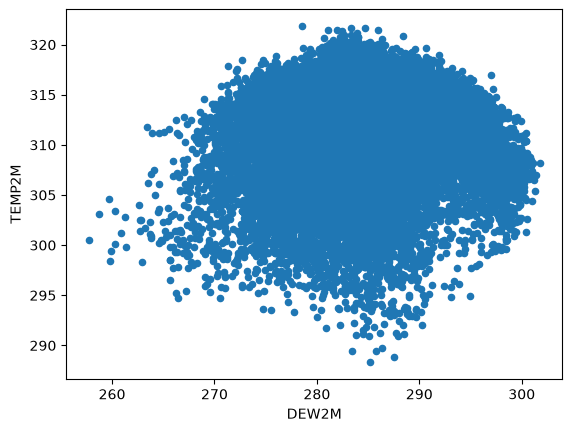

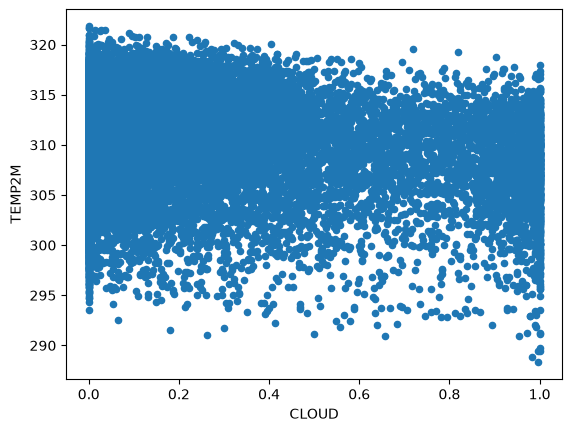

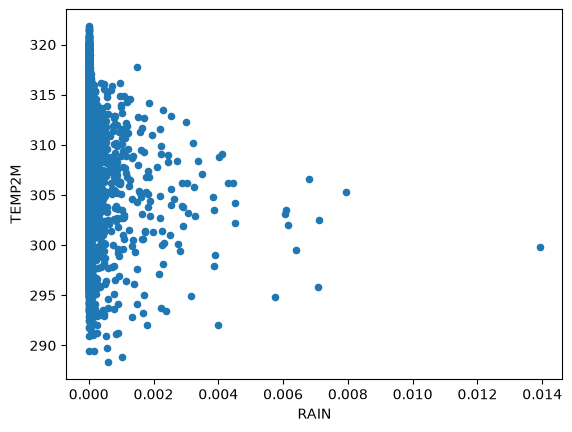

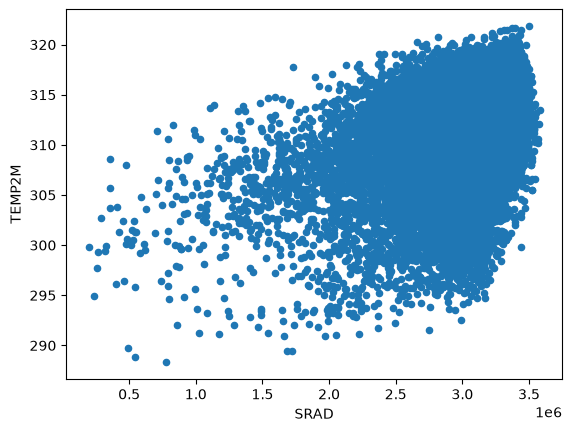

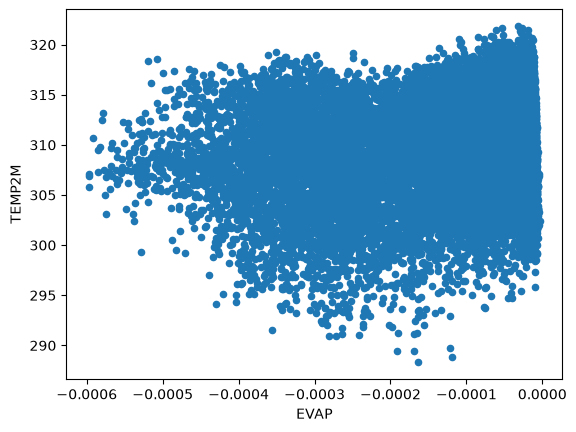

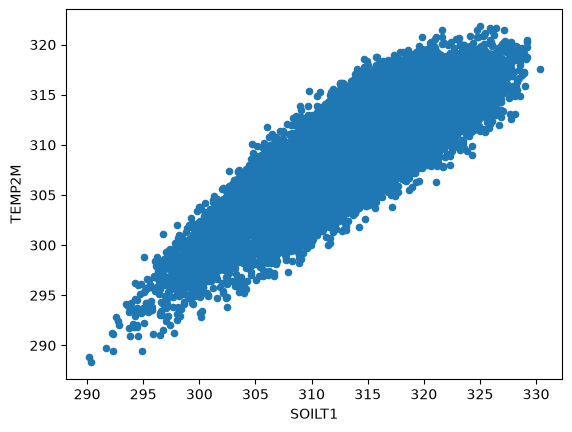

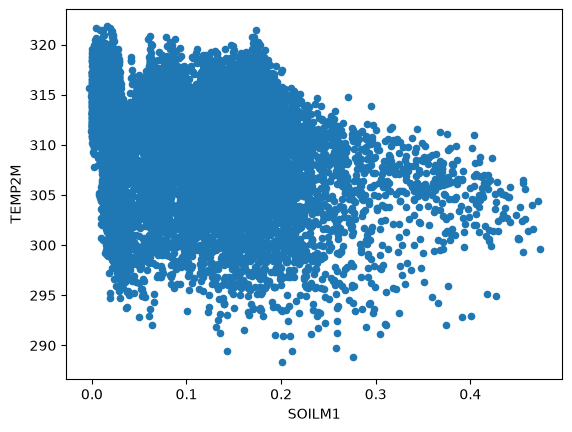

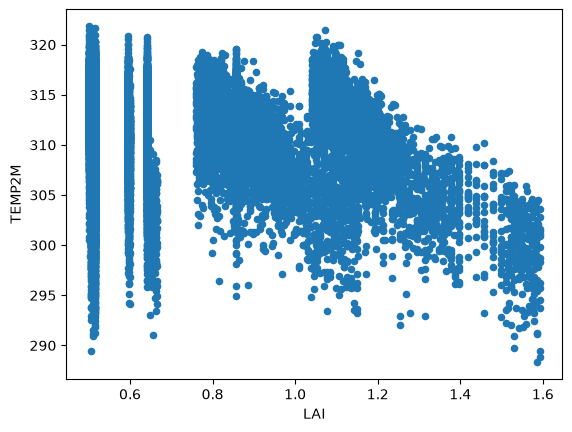

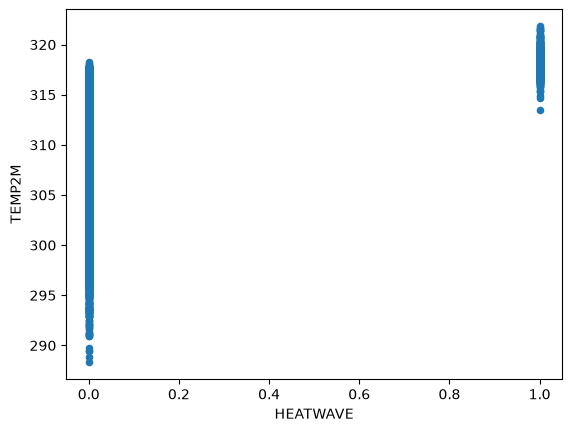

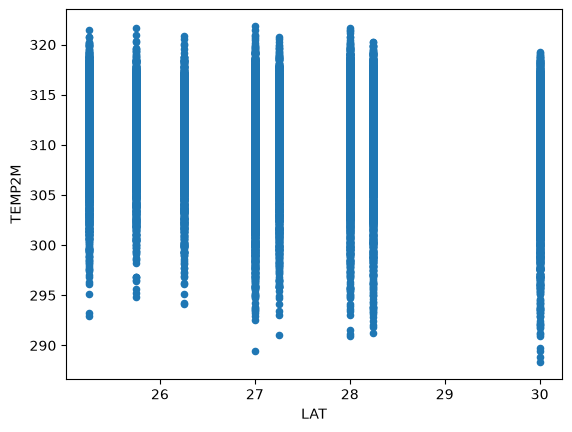

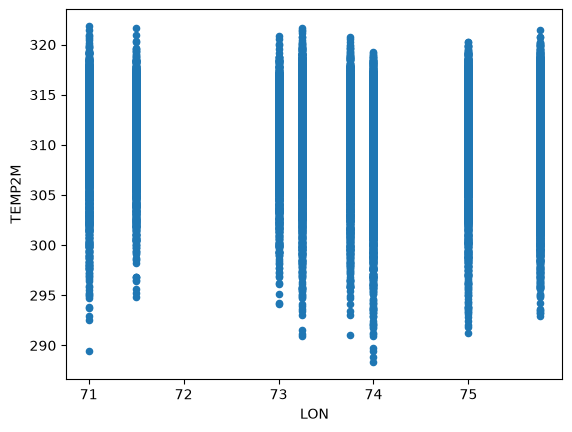

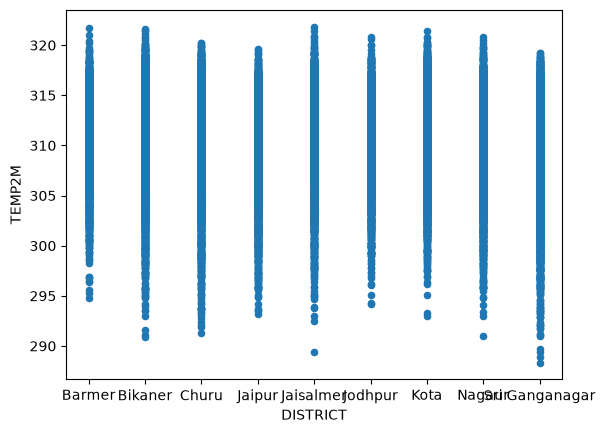

In [34]:
for i in data.columns:
    data.plot.scatter(x=i, y="TEMP2M")

From these scatter plots, we can see that "SOILT1"(soil data) showcases a positive correlation to TEMP2M(the temperature). We can directly correlate this with soil data correlating with heatwaves. Let's quickly prove this:

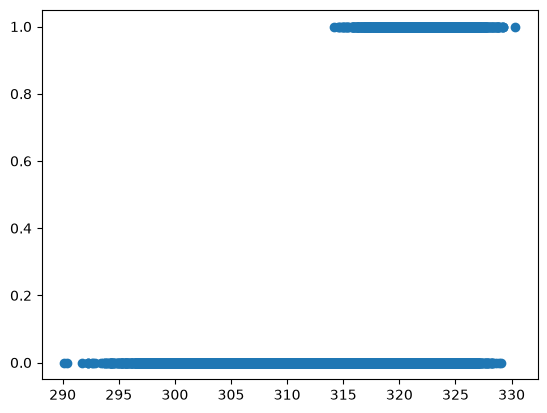

In [39]:
plt.scatter(x=data.SOILT1, y=data.HEATWAVE)

Because our target variable is HEATWAVE and is a binary output, we can't do much more effective analysis here, so let's jump into building a model that can predict the relation between all these feature columns and our target variable. 

## Data Pre-Processing

Let's now process our data accordingly to fit the model to. 

First, let's split up our dataset into **X** and **Y** variables

In [42]:
X = data.drop("HEATWAVE", axis=1)
Y = data["HEATWAVE"]

Let's not forget we promised ourselfs to remove the one column that isn't numerical!:

In [44]:
X_n = X.select_dtypes(exclude=object)

The Regularization models we will use later on require the data to be scaled, and plus, it is always a good practice to have all your data on the same scale:

In [45]:
s = StandardScaler()
X_ss = s.fit_transform(X_n)

To potentially increase our accuracy for our model, let's add some Polynomial Features. Note that even if these overcomplexify the model, that's exactly why we are regulating the model as well:

In [46]:
p = PolynomialFeatures(degree=2, include_bias=False)
X_ssp = p.fit_transform(X_ss)

One last step: let's take everything and split the dataset into it's respective training and testing sets with a 70/30 split:

In [72]:
X_TRAIN, X_TEST, Y_TRAIN, Y_TEST = train_test_split(X_ss, Y, test_size=.30)

## Model Training

Now that our data is ready, let's begin to train our models. We will be comparing 3 different models:
* Linear Regression with no Regularization
* Linear Regression with **Ridge(L2)** Regularization
* Linear Regression with **LASSO(L1)** Regularization
We will evaluate the accuracy of each of these models using R2 scoring

Let's start off with no regularization and just vanilla Linear Regression:

In [73]:
l = LinearRegression()
l.fit(X_TRAIN, Y_TRAIN)
Y_PREDICT = l.predict(X_TEST)
r2_score(Y_TEST, Y_PREDICT)

0.17685553875769078

Our score isn't looking too good, with the R2 score only being around 0.1726

Now, let's implement **Ridge Regularization**. We will implement a model for 20 alphas, each equally spaced between 0 and 0.1(courtesy of **NumPy**):

In [79]:
alphas = np.linspace(0, 0.1, 20)

maxR2 = 0
for alpha in alphas:
    r = Ridge(alpha=alpha)
    r.fit(X_TRAIN, Y_TRAIN)
    Y_PREDICT = r.predict(X_TEST)
    r2score = r2_score(Y_TEST, Y_PREDICT)
    print(r2score)
    maxR2 = max(maxR2, r2score)
print("Max R2 Score: ", maxR2)

0.172409694830978
0.15928742559321785
0.17398793443958438
0.17072126865818238
0.16863973387147768
0.17781115114315516
0.17370882728057335
0.16269365453266682
0.16489128074480108
0.1773045944395224
0.17775157202448066
0.16648053154769482
0.16785834555276036
0.17058940631233166
0.18347707996256712
0.17604552174188404
0.17682450577075304
0.17825228959471462
0.17769574665538979
0.15328627470966005
Max R2 Score:  0.18347707996256712


Looking at all these R2 scores, they don't look much different to our previous results, with the highest score being almost exactly the same. The R2 score proceeds to decrease as the alpha value increased. This shows us that we may be decreasing feature coefficients when we don't want to. 

And lastly, we have **LASSO Regularization**. From what we saw from the previous results, we don't expect a score too high, maybe even lower. One thing to note is that multiple alphas weren't considered here due to the time complexity of LASSO due to it's gradient descent:

In [17]:
ll = Lasso(alpha=0.001, max_iter=100000)
ll.fit(X_TRAIN, Y_TRAIN)
Y_PREDICT = ll.predict(X_TEST)
r2_score(Y_TEST, Y_PREDICT)

0.16860348671806236

Unfortunately, it turns out our score did, in fact, decrease from before. 

## Conclusions

From the 3 models we trained, we achieved a max model R2 score of 0.1726557. While this is low, we can learn a lot from this. With major factors like the target variable being a binary value, trying to be predicted, as well as the uncertain quality of the dataset, these and many other things may very well be the reasons that our model performed well. The key finding was that the accuracy decreased when we both increased the alpha value on Ridge Regularization and when we used LASSO Regularization. In short, it may be claimed that our model was too simple/not complex enough and needs more features. In the future, more Polynomial features may be added, as well as adding for loops for alpha for LASSO regularization. It should be noted that while this may increase accuracy, especially with more Polynomial features, time complexity will exponentially increase, so the amount of time and computational power readily available greatly affects this as well. Note that after this process, different training-test splits were tested, and the R2 score didn't change much, further suggesting the need for either extra features, a better dataset, or more complex techniques.

Copyright @ IBM Corporation. All rights reserved. This notebbok was created by Aarush Muthukrishnan. 
